# ***Parkinson Disease Detection***
We will detect Parkinson's disease using multimodal data, that is, using handwritten images of healthy and Sick people, and using features extracted from audio recordings of healthy and Sick people.


In [1]:
# link with google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### ***Detection with images dataset***

We will classify Parkinson's disease based on handwriting images in two ways, and then compare them to find out which method achieves higher classification performance. The two methods are:


1.   Convolutional Neural Network
2.   Extract features using Hog Features method






### ***CNN Model***

In [ ]:
# import modules
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam


In [ ]:
# Build CNN model
def create_cnn_model(input_shape):
    # Create a sequential model
    model = Sequential()

    # First layer: Convolutional layer with 32 filters of size 3x3
    model.add(Conv2D(32, (3, 3), input_shape=input_shape))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2))) # Max pooling to reduce image size

    # Second layer: Convolutional layer with 64 filters of size 3x3
    model.add(Conv2D(64, (3, 3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Third layer: Convolutional layer with 128 filters of size 3x3
    model.add(Conv2D(128, (3, 3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Fourth layer: Convolutional layer with 128 filters of size 3x3
    model.add(Conv2D(128, (3, 3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten()) # Flatten the output of the previous layer

    # Fifth layer: Fully connected layer with 512 units
    model.add(Dense(512))
    model.add(Activation('relu'))
    model.add(Dropout(0.5)) # Dropout to prevent overfitting

    # Last layer: Fully connected layer with one unit for binary output
    model.add(Dense(1))
    model.add(Activation('sigmoid')) # Sigmoid activation for binary classification

    # Compile the model with binary cross-entropy loss and Adam optimizer
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model


In [ ]:
img_width, img_height = 256, 256
train_data_dir = '/content/drive/MyDrive/multimodal project/datasets/drawings/testing'
validation_data_dir = '/content/drive/MyDrive/multimodal project/datasets/drawings/training'
epochs = 100
batch_size = 32

input_shape = (img_width, img_height, 3)

# Create the CNN model
model = create_cnn_model(input_shape)

# Image data augmentation
train_datagen = ImageDataGenerator(
    zoom_range=0.2,
    height_shift_range=0.1,
    rotation_range=45,
    rescale=1./255
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Generate batches of augmented training and testing data
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary'
)

Found 147 images belonging to 2 classes.
Found 60 images belonging to 2 classes.


In [ ]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.n // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.n // batch_size
)

Epoch 1/100
4/4 [==============================] - 82s 18s/step - loss: 0.8190 - accuracy: 0.5130 - val_loss: 0.7004 - val_accuracy: 0.5000
Epoch 2/100
4/4 [==============================] - 3s 746ms/step - loss: 0.6973 - accuracy: 0.5043 - val_loss: 0.7426 - val_accuracy: 0.4062
Epoch 3/100
4/4 [==============================] - 3s 759ms/step - loss: 0.7158 - accuracy: 0.5217 - val_loss: 0.6944 - val_accuracy: 0.4688
Epoch 4/100
4/4 [==============================] - 4s 1s/step - loss: 0.6944 - accuracy: 0.4957 - val_loss: 0.6950 - val_accuracy: 0.5000
Epoch 5/100
4/4 [==============================] - 3s 779ms/step - loss: 0.6968 - accuracy: 0.4522 - val_loss: 0.6928 - val_accuracy: 0.5312
Epoch 6/100
4/4 [==============================] - 3s 816ms/step - loss: 0.6917 - accuracy: 0.5156 - val_loss: 0.7051 - val_accuracy: 0.4375
Epoch 7/100
4/4 [==============================] - 4s 939ms/step - loss: 0.6955 - accuracy: 0.5078 - val_loss: 0.7015 - val_accuracy: 0.4375
Epoch 8/100
4/4 [

### ***Random Forest models with hog features Extraction***



In [ ]:
# import modules
from imutils import paths
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from skimage import feature
import cv2
import numpy as np
import os
import joblib

In [ ]:
# Function to extract HOG features from an image
def hog_features(image):
    f
eatures = feature.hog(image, orientations=9,
                           pixels_per_cell=(10, 10), cells_per_block=(2, 2),
                           transform_sqrt=True, block_norm="L1")
    return features
# Function to process images in a directory and extract features and labels
def process_images(directory_path):
    image_paths = list(paths.list_images(directory_path))
    data = []
    labels = []
    for img_path in image_paths:
        label = img_path.split(os.path.sep)[-2] # Extract label from image path
        img = cv2.imread(img_path) # Read image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Convert to grayscale
        img = cv2.resize(img, (250, 250), fx=0.5, fy=0.5) # Resize image
        img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1] # Apply thresholding
        features = hog_features(img) # Extract HOG features
        data.append(features)
        labels.append(label)
    return (np.array(data), np.array(labels))

# Function to train a RandomForestClassifier model and evaluate its performance
def train_model(data_directory):
    model = RandomForestClassifier(random_state=2)
    training_path = os.path.sep.join([data_directory, "training"])
    testing_path = os.path.sep.join([data_directory, "testing"])
    train_data, train_labels = process_images(training_path)
    test_data, test_labels = process_images(testing_path)
    encoder = LabelEncoder()
    train_labels = encoder.fit_transform(train_labels)
    test_labels = encoder.transform(test_labels)
    model.fit(train_data, train_labels)
    train_predictions = model.predict(train_data)
    test_predictions = model.predict(test_data)

    train_accuracy = accuracy_score(train_labels, train_predictions)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    precision_train = precision_score(train_labels, train_predictions)
    recall_train = recall_score(train_labels, train_predictions)
    f1_train = f1_score(train_labels, train_predictions)
    precision_test = precision_score(test_labels, test_predictions)
    recall_test = recall_score(test_labels, test_predictions)
    f1_test = f1_score(test_labels, test_predictions)

    return model, train_accuracy, test_accuracy, precision_train, recall_train, f1_train, precision_test, recall_test, f1_test

# Function to save a trained model to a file
def save_model(model, model_path):
    joblib.dump(model, model_path)

# Function to load a trained model from a file
def load_model(model_path):
    return joblib.load(model_path)

# Function to predict the class of a new image using a trained model
def predict_image(model, image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (250, 250), fx=0.5, fy=0.5)
    img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    features = hog_features(img)
    prediction = model.predict([features])
    return prediction


In [ ]:
# Define the directory containing the image data
data_directory = "/content/drive/MyDrive/multimodal project/datasets/drawings"

# Train the model and get evaluation metrics
trained_model, train_accuracy, test_accuracy, precision_train, recall_train, f1_train, precision_test, recall_test, f1_test = train_model(data_directory)

# Print the evaluation metrics
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Precision (Train):", precision_train)
print("Recall (Train):", recall_train)
print("F1 Score (Train):", f1_train)
print("Precision (Test):", precision_test)
print("Recall (Test):", recall_test)
print("F1 Score (Test):", f1_test)

Training Accuracy: 1.0
Testing Accuracy: 0.8333333333333334
Precision (Train): 1.0
Recall (Train): 1.0
F1 Score (Train): 1.0
Precision (Test): 0.8571428571428571
Recall (Test): 0.8
F1 Score (Test): 0.8275862068965518


In [ ]:
# save the model
model_path = "/content/drive/MyDrive/multimodal project/models/drawing_model.pkl"
save_model(trained_model, model_path)

### ***Using the Model***

In [9]:
import os
import pickle
import cv2
import matplotlib.pyplot as plt
import joblib
from skimage import feature

In [12]:
# Function to extract HOG features from an image
def hog_features(image):
    features = feature.hog(image, orientations=9,
                           pixels_per_cell=(10, 10), cells_per_block=(2, 2),
                           transform_sqrt=True, block_norm="L1")
    return features

# Function to load a trained model from a file
def load_model(model_path):
    return joblib.load(model_path)

# Function to predict image
def predict_image(model, image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (250, 250), fx=0.5, fy=0.5)
    img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    features = hog_features(img)
    prediction = model.predict([features])
    return prediction, img

# Function to upload and predict image locally
def upload_and_predict():
    # Prompt user to enter image file path
    image_path = input("Enter the path to the image file: ")

    # Check if the entered file path is valid
    if not os.path.isfile(image_path):
        print("Invalid file path. Please enter a valid path.")
        return

    # Predict using the model
    prediction, img = predict_image(loaded_model, image_path)

    # Display the image
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    if prediction == 1:
        plt.title("You are sick\n")
    else:
        plt.title("You do not have Parkinson's disease\n")
    plt.show()

In [13]:
# Load the saved model
model_path = "/content/drive/MyDrive/multimodal project/models/drawing_model.pkl"
loaded_model = load_model(model_path)

Enter the path to the image file: /content/drive/MyDrive/multimodal project/datasets/drawings/images for Using/pd3.png


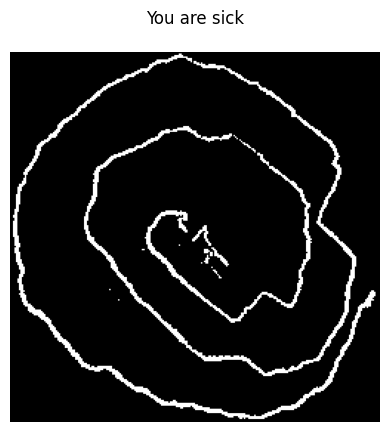

In [15]:
# Call the function to upload and predict image
upload_and_predict()